# Neural network classifier

___

## Data onboarding and preprocessing

### Load data

In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.typing import NDArray

np.random.seed(42)

dir_path = "../training_data"

names, labels, samples = [], [], []
for label in range(10): 
    for file_path in [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and f"stroke_{label}" in f]: 
        names.append(os.path.splitext(os.path.basename(file_path))[0])
        labels.append(label)
        samples.append(pd.read_csv(file_path, header=None))

### Interpolate data

Define function to interpolate data

In [2]:
# Define function to interpolate a sample
def interpolate_sample(sample: NDArray, target_length: int):
    
    # Cumulative arc length
    diffs = np.diff(sample, axis=0)
    segment_len = np.sqrt(np.sum(diffs**2, axis=1))
    cumlen = np.concatenate(([0], np.cumsum(segment_len)))
    total_len = cumlen[-1]
    
    # Create target archs
    target_arc_len = np.linspace(0, total_len, target_length)
    
    # Interpolate
    interpolated = np.zeros((target_length, sample.shape[1]))
    for coord  in range(sample.shape[1]):
        interpolated[:, coord] = np.interp(target_arc_len, cumlen, sample[:, coord])
    
    # Return interpolated sample
    return interpolated

### Project to 2D

Define function to project 3d data to 2d

In [3]:
from sklearn.decomposition import PCA

# Define function to project 3D data to 2D using PCA
def project_to_2d(data: pd.DataFrame|NDArray, keep_order: bool=True, keep_dims: bool=False) -> NDArray:
    
    # Convert data to numpy array if needed
    if isinstance(data, pd.DataFrame): data = data.to_numpy()

    # Apply PCA
    pca = PCA(n_components=data.shape[1]).fit(data)
    scores = pca.fit_transform(data)
    loadings = pca.components_ 

    # Find principal components that align best with the original axes
    if keep_order: 
        order = np.argmax(np.abs(loadings), axis=0)[:(data.shape[1] if keep_dims else 2)]
    else: 
        order = np.arange(data.shape[1]) if keep_dims else np.arange(2)

    # Return reordered projected data
    return scores[:, order]

### Convert data to images

Define function to convert 2D coordinates to images

In [4]:
from typing import List

# Define a function to convert 2D/3D coordinates to images
def convert_to_image(data_projected: NDArray, size: tuple) -> NDArray: 

    # Initialize empty image
    width, height = size 
    image = np.zeros((height, width))

    # Center and scale the data to range [-1, 1]
    min_values, max_values = np.min(data_projected, axis=0), np.max(data_projected, axis=0)
    data_projected = data_projected - (min_values + max_values) / 2
    data_projected = data_projected / np.max(np.abs(data_projected)) # Scale to range [-1, 1]

    # Extract x and y data and scale to [0, N-1] (pixel coordinates)
    x_data, y_data = data_projected[:, 0], data_projected[:, 1] # Note: swap x and y for image coordinates
    x_data = x_data * ((width-1) / 2) + ((width-1) / 2)
    y_data = y_data * ((height-1) / 2) + ((height-1) / 2)

    # Compute floor and ceil values
    x_floor, x_ceil = np.floor(x_data).astype(int), np.ceil(x_data).astype(int)
    y_floor, y_ceil = np.floor(y_data).astype(int), np.ceil(y_data).astype(int)

    # Convert x, y data to pixels in an image
    image[y_floor, x_floor] += (1 - y_data % 1) * (1 - x_data % 1)
    image[y_ceil, x_ceil] += (y_data % 1) * (x_data % 1)
    image[y_floor, x_ceil] += (x_data % 1) * (1 - y_data % 1)
    image[y_ceil, x_floor] += (1 - x_data % 1) * (y_data % 1)

    # Clip the pixel values to range [0, 1]
    image = np.clip(image, 0, 1)  

    # Flip the image (so that it is not upside down)
    image = np.flip(image, 0)
    
    return image

### Preprocess the data

Define a function to interpolate the data, project the 3d samples to 2d, convert 2d data to images and flatten the images to 1d vectors

In [5]:
from typing import Optional

# Define a function to preprocess a single sample
def preprocess(sample: NDArray|pd.DataFrame, use_interpolation: bool=True, 
               use_PCA: bool=True, use_convert_to_image: bool=True, use_flatten: bool=True,
               target_len: Optional[int]=None, img_size: tuple=(16, 16)) -> NDArray:  
    assert use_interpolation or target_len is None, "Interpolation is enabled but target len was not provided"

    # Convert sample to numpy array if necessary
    if isinstance(sample, pd.DataFrame): sample = sample.to_numpy()

    # Interpolate sample (if target len was provided)
    if use_interpolation: sample = interpolate_sample(sample, target_len) 

    # Project sample to 2D (use PCA or take the first 2 dimensions)
    sample = project_to_2d(sample) if use_PCA else sample[:, :2]

    # Convert 2D coordinates to pixels in an image
    sample = convert_to_image(sample, img_size) if use_convert_to_image else sample

    # Return the image as a flattened vector 
    return sample.flatten() if use_flatten else sample

Preprocess the samples and convert labels to numpy array

In [6]:
# Define interpolation target length and image size
target_len = max([len(s) for s in samples])
img_size = (16, 16)

# Preprocess samples
# Parameters: sample, use_interpolation, use_PCA, use_convert_to_image, use_flatten, target_len, img_size
X = np.array([preprocess(s, True, True, True, True, target_len, img_size) for s in samples])

# Convert labels to a numpy array
y = np.array(labels)

Visualize preprocessed images

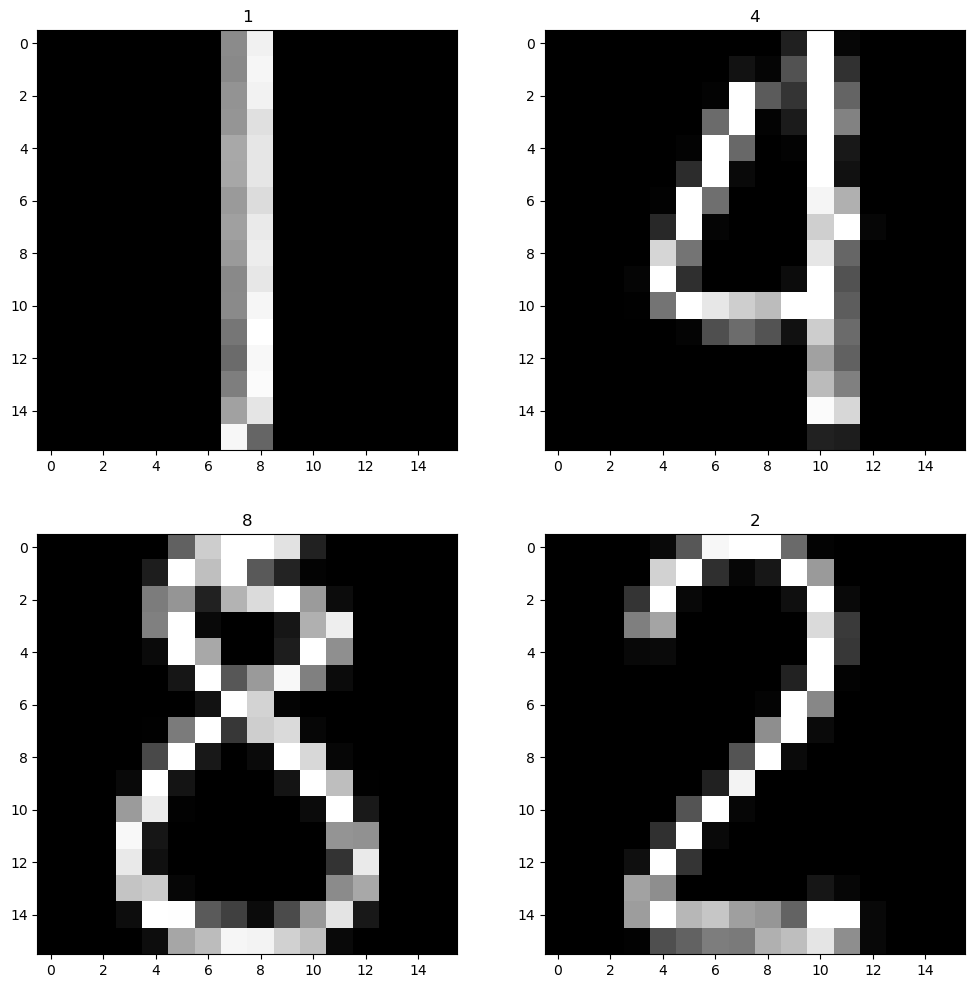

In [7]:
# Select random images
index = np.random.choice(len(X), 4)
selected_images = [X[i].reshape(*img_size) for i in index]
selected_labels = [labels[i] for i in index]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()
for i, (image, label) in enumerate(zip(selected_images, selected_labels)): 
    axes[i].imshow(image, cmap='Grays_r')
    axes[i].set_title(label)
plt.show()

___

## Training the model 

### Split data to training and test sets

In [8]:
from neural_network import *
from sklearn.model_selection import train_test_split

# One-hot encode y
y_encoded = one_hot_encode(y, np.arange(10))

# Split the data to training/validation and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.20, stratify=y, random_state=42)

### Define model

In [9]:
from numpy.random import uniform

model = NeuralNetworkClassifier(
    Dense(uniform(-0.1, 0.1, size=(X_train.shape[1], 256)), np.zeros(256), ReLU),
    Dense(uniform(-0.1, 0.1, size=(256, 128)), np.zeros(128), ReLU), 
    Dense(uniform(-0.1, 0.1, size=(128, 10)), np.zeros(10), Softmax)
)

### Train the model 

  0%|          | 27/10000 [00:01<08:17, 20.05it/s]


Model accuracy (training set): 98 %
Model accuracy (test set): 96 %


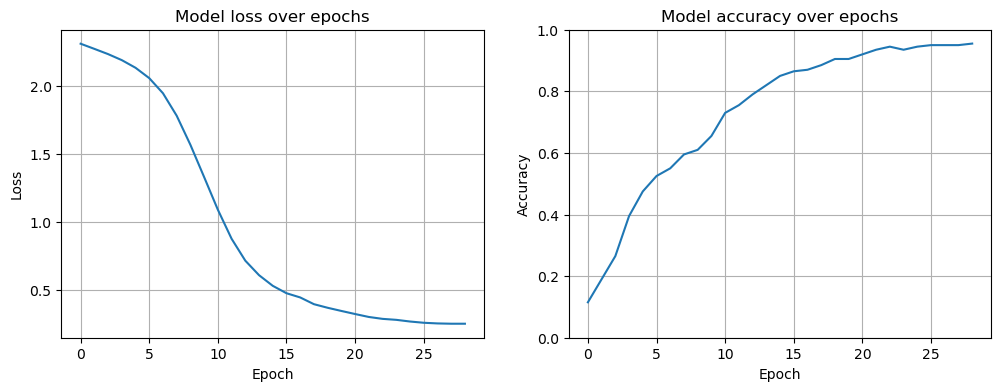

In [10]:
import matplotlib.pyplot as plt

# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 10000, 16, 0.1, 1e-3, 1e-8
criterion = CategoricalCrossEntropySoftmax()

# Train the model  
loss_history, accuracy_history = train(model, X_train, y_train, X_val=X_test, y_val=y_test,
    criterion=criterion, max_iter=epochs, batch_size=batch_size, learning_rate=learning_rate, 
    tol=tol, min_loss=min_loss, verbose=True
)

# Visualize training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Measure accuracy
y_pred = model.forward(X_train)
print(f"Model accuracy (training set): {accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

# Measure accuracy
y_pred = model.forward(X_test)
print(f"Model accuracy (test set): {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

Further training

  0%|          | 9/10000 [00:00<08:01, 20.73it/s]


Model accuracy (training set): 98 %
Model accuracy (test set): 95 %


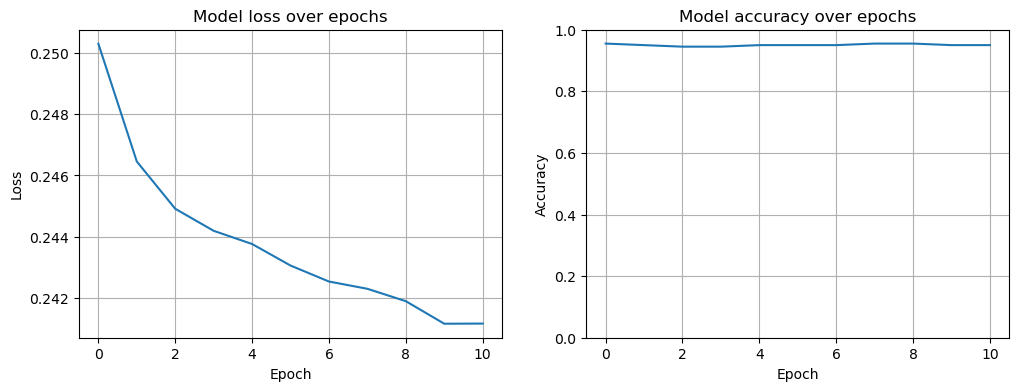

In [11]:
# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 10000, 16, 0.01, 1e-4, 1e-8
criterion = CategoricalCrossEntropySoftmax()

# Train the model  
loss_history, accuracy_history = train(model, X_train, y_train, X_val=X_test, y_val=y_test,
    criterion=criterion, max_iter=epochs, batch_size=batch_size, learning_rate=learning_rate, 
    tol=tol, min_loss=min_loss, verbose=True
)

# Visualize training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Measure accuracy
y_pred = model.forward(X_train)
print(f"Model accuracy (training set): {accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

# Measure accuracy
y_pred = model.forward(X_test)
print(f"Model accuracy (test set): {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

### Store the trained model 

In [12]:
import pickle

trained_models_dir = os.path.join("..", "trained_models")
model_path = os.path.join(trained_models_dir, "NN_classifier.pkl")

with open(model_path, "wb") as f: pickle.dump(model, f)

___

## Combining the preprocessing pipeline and NN classifier to a single function

In [13]:
from typing import Callable

def preprocess_samples(samples: List[NDArray|pd.DataFrame]) -> NDArray: 
    target_len = max([len(s) for s in samples])
    X = np.array([preprocess(s, target_len=target_len, img_size=img_size) for s in samples])
    return X

def classify(samples: List[NDArray|pd.DataFrame], predict: Callable, preprocess: Callable) -> NDArray: 

    # Preprocess the samples
    X = preprocess_samples(samples)
    
    # Predict the classes of the samples
    return predict(X)

In [14]:
# Select random test set 
index = np.random.choice(len(samples), 100).astype(int)
test_datas, test_labels = [samples[i] for i in index], [labels[i] for i in index]

# Predict the test set using the classify-function
predicted_labels = classify(test_datas, model.predict, lambda s : preprocess(s, target_len=target_len, img_size=img_size))

# Measure prediction accuracy
print(f"Classification accuracy: {accuracy_score(test_labels, predicted_labels)*100:.0f} %")

Classification accuracy: 98 %
